In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables

import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import (
    MAE, 
    SDOMLDataModule, 
    patch_attn_layers, 
    visualize_head,
    inverse_log_norm)
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

In [3]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-06-19 20:05:57.454 | INFO     | sdofmv2.core.datamodule:setup:635 - Train dataloader is ready!
2026-06-19 20:05:57.456 | INFO     | sdofmv2.core.datamodule:setup:636 - Dataset size: 223044
2026-06-19 20:05:57.582 | INFO     | sdofmv2.core.datamodule:setup:654 - Validation dataloader is ready!
2026-06-19 20:05:57.584 | INFO     | sdofmv2.core.datamodule:setup:655 - Dataset size: 23123
2026-06-19 20:05:57.685 | INFO     | sdofmv2.core.datamodule:setup:673 - test dataloader is ready!
2026-06-19 20:05:57.687 | INFO     | sdofmv2.core.datamodule:setup:674 - Dataset size: 24618


In [4]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [5]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_tnzqmrb2_mae_epoch=4-step=3600-val_loss=0.06.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-06-19 20:06:05.922 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.2


In [6]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00",
    "2016-12-25 00:12:00",
    "2017-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00'), Timestamp('2016-12-25 00:12:00'), Timestamp('2017-12-25 00:12:00')]


In [7]:
# Patch attention layers
attn_maps = patch_attn_layers(model)

with torch.no_grad():
    latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)
latent_size = latent.shape[1] - 1
ids_keep = torch.argsort(ids_restore.squeeze())[:latent_size]
feature_maps = latent[0, 1:, :]

In [8]:
# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(chan_types):

        if ch_id >= 9:
            x_set[i_img, ch_id, 0, :, :] = inverse_log_norm(
                x_set[i_img, ch_id, 0, :, :],
                data_module.normalization_stat,
                ch,
                cfg.data.sdoml.normalization.scaler_factor,
            )

In [9]:
# attn_maps = patch_attn_layers(model)

# with torch.no_grad():
#     latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)


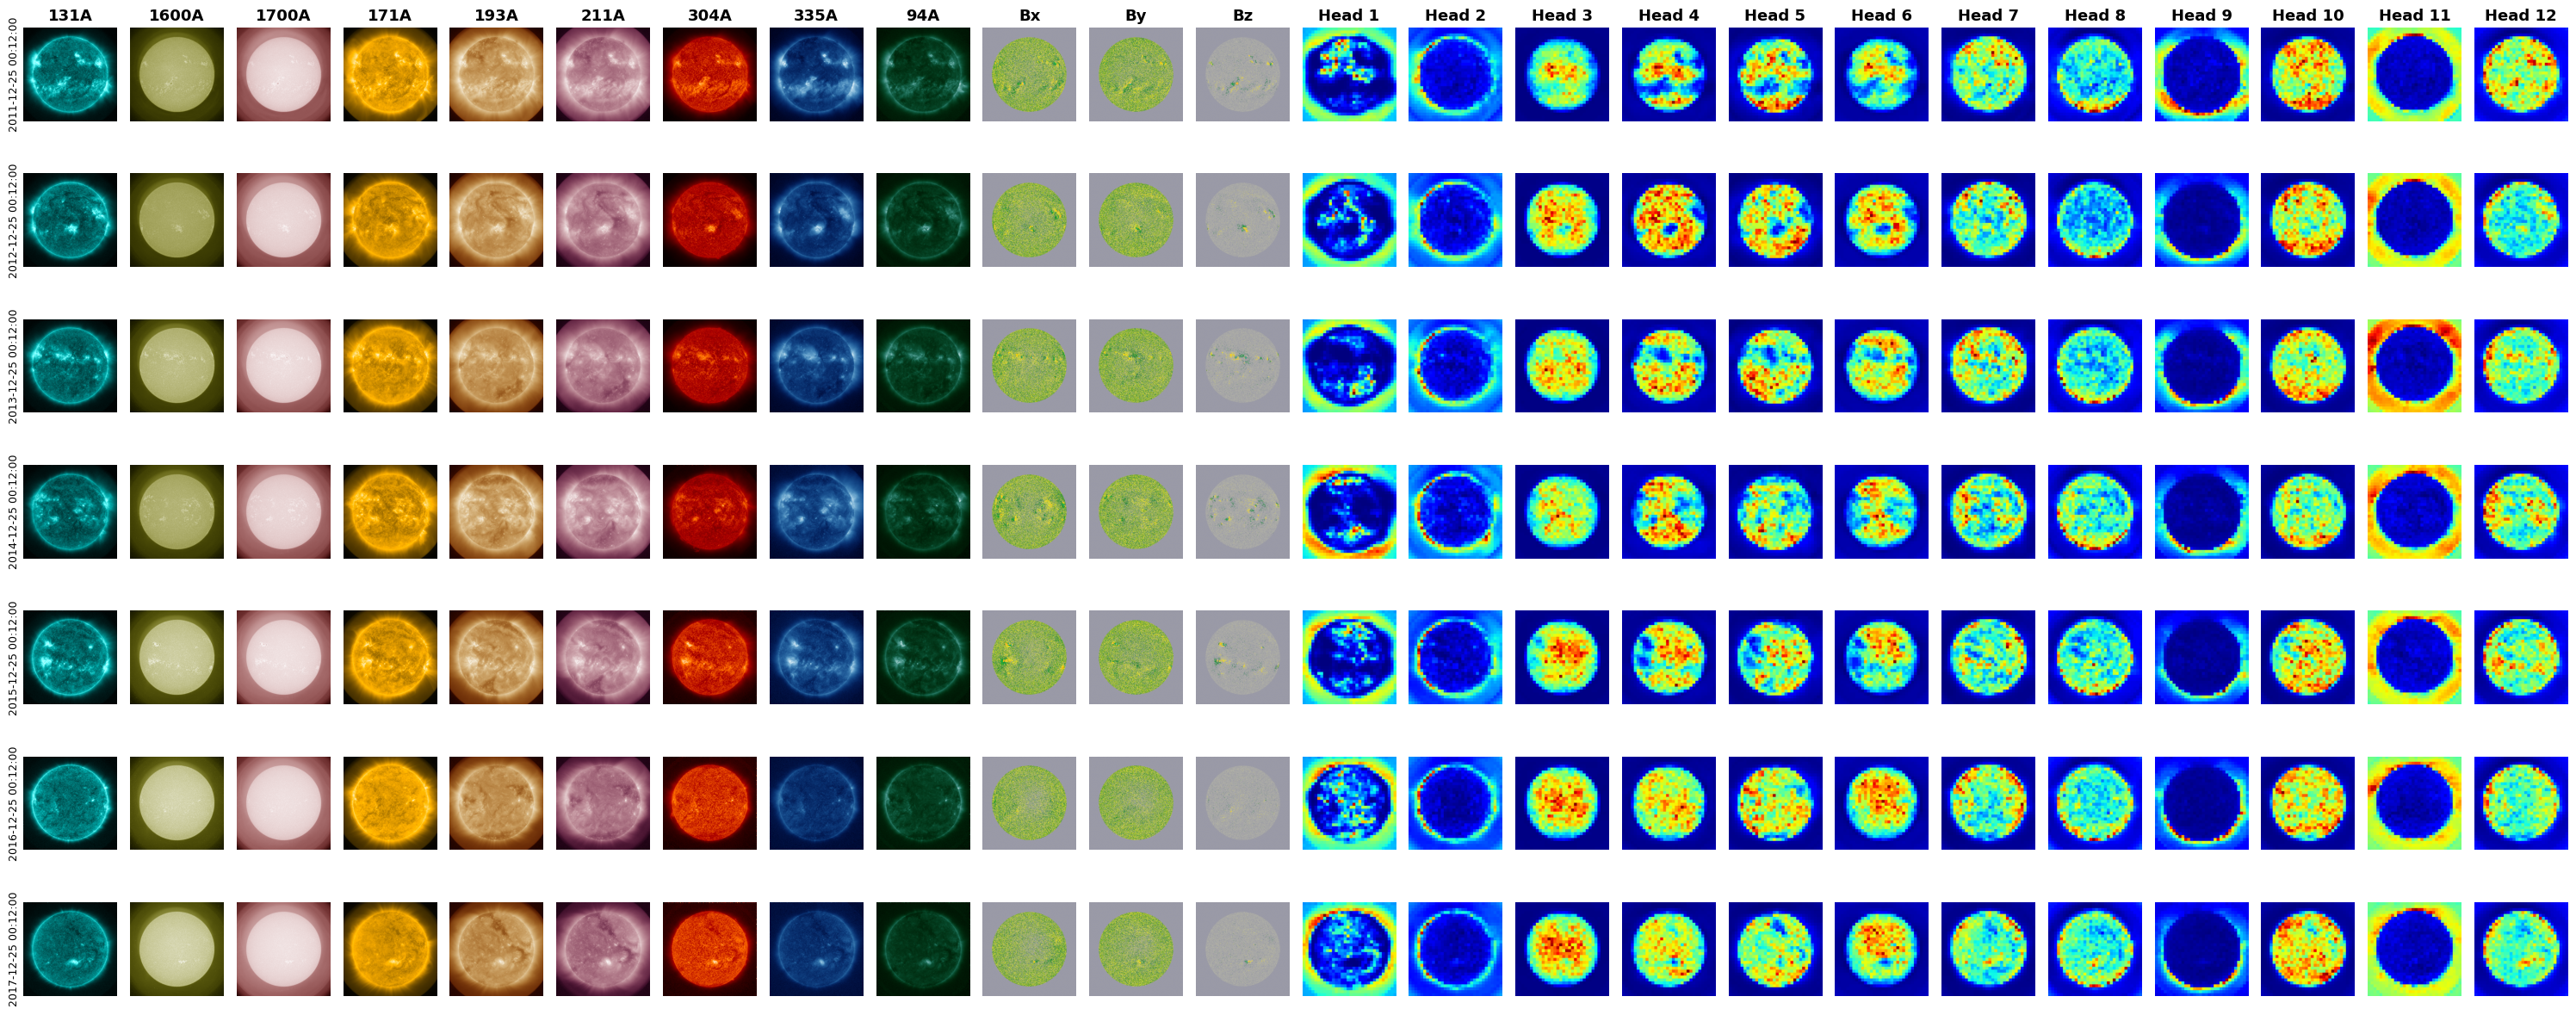

In [10]:
num_images = x_set.shape[0]
num_channels = x_set.shape[1]
num_heads = attn_maps[0].shape[1]
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

fig, axs = plt.subplots(
    num_images, num_heads + num_channels, figsize=(30, 12), squeeze=False
)

for i in range(num_images):

    attn = attn_maps[0][i, :, 1:, 1:]  # [num_head, num_patch, num_patch]
    num_heads = attn.shape[0]
    full_order = torch.argsort(ids_restore[i])  # Invert argsort
    num_kept = attn.shape[1]
    ids_keep = full_order[:num_kept]
    attn_received = attn.mean(axis=1)

    for i_col, ch_name in enumerate(chan_types):
        if i==0:
            axs[i, i_col].set_title(f"{ch_name}", fontsize=13, fontweight='bold')
        axs[i, i_col].imshow(x_set[i, i_col, 0, :, :], cmap=cms[i_col], norm=norm if (i_col>=9 and i_col<=11) else None)
        axs[i, i_col].axis("off")

    for h in range(num_heads):
        if i==0:
            axs[i, h + num_channels].set_title(f"Head {h+1}", fontsize=13, fontweight='bold')
        head_attn = attn_received[h, :]
        heatmap = visualize_head(head_attn, ids_keep, 512, 16)
        axs[i, h + num_channels].imshow(heatmap, cmap="jet")
        axs[i, h + num_channels].axis("off")

    axs[i][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[i]}", 
        ha='center', 
        va='center', 
        fontsize=9, 
        rotation=90,
        transform=axs[i][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.tight_layout()
plt.savefig("attention_map_ALL.pdf", dpi=300, bbox_inches="tight")
# plt.show()